In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import datasets, layers, models, losses
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split

In [3]:
base_path = "/kaggle/input/datasets/jehanbhathena/weather-dataset"

def find_data_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if dirnames and not filenames:
            sub_has_images = any(
                any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(os.path.join(dirpath, d)))
                for d in dirnames
            )
            if sub_has_images:
                return dirpath
    return root

data_dir = find_data_dir(base_path)
print("data_dir:", data_dir)
print("classes:", sorted(os.listdir(data_dir)))

data_dir: /kaggle/input/datasets/jehanbhathena/weather-dataset/dataset
classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [5]:
IMG_SIZE = (64, 64)  

full_ds = image_dataset_from_directory(
    data_dir,
    image_size=IMG_SIZE,
    batch_size=10000,   
    shuffle=True,
    seed=42,
    label_mode="int",
)

class_names = full_ds.class_names
print("class_names:", class_names)

for images, labels in full_ds.take(1):
    all_images = images.numpy()
    all_labels = labels.numpy()

print(all_images.shape, all_labels.shape)

Found 6862 files belonging to 11 classes.
class_names: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
(6862, 64, 64, 3) (6862,)


In [6]:
train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, all_labels, test_size=0.15, random_state=42, stratify=all_labels
)

print(train_images.shape)
print(test_images.shape)

(5832, 64, 64, 3)
(1030, 64, 64, 3)


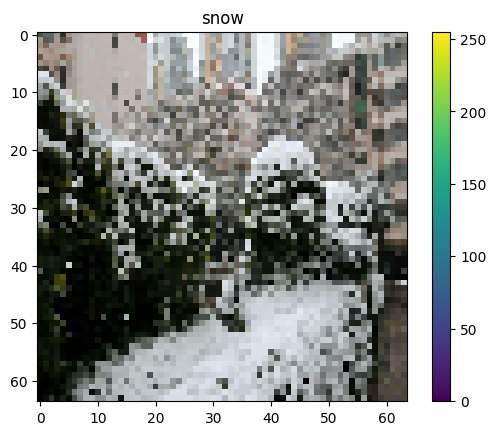

In [8]:
plt.figure()
plt.imshow(train_images[42].astype('uint8'))
plt.colorbar()
plt.grid(False)
plt.title(class_names[train_labels[42]])
plt.show()

In [9]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
train_images = train_images / 255.0
test_images = test_images / 255.0

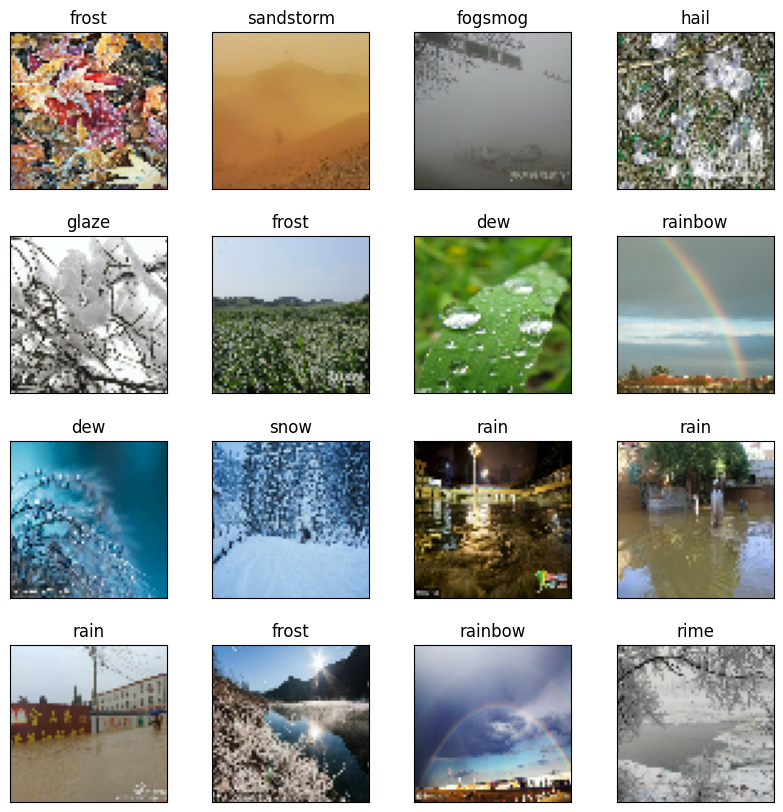

In [10]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.subplots_adjust(hspace=.3)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i]])
plt.show()

In [11]:
X_train = train_images
X_test = test_images
print(X_train.shape)

(5832, 64, 64, 3)


In [13]:
tf.random.set_seed(42)

num_classes = len(class_names)

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss=losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273,675 (4.86 MB)

 Trainable params: 1,273,675 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.fit(X_train, train_labels, validation_split=0.15, epochs=10, batch_size=64)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.8342 - loss: 0.4943 - val_accuracy: 0.7120 - val_loss: 1.0714
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.8426 - loss: 0.4679 - val_accuracy: 0.7006 - val_loss: 1.1531
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.8588 - loss: 0.4266 - val_accuracy: 0.7189 - val_loss: 1.1161
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - accuracy: 0.8860 - loss: 0.3512 - val_accuracy: 0.7131 - val_loss: 1.2153
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 0.8901 - loss: 0.3473 - val_accuracy: 0.7086 - val_loss: 1.2803
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.8890 - loss: 0.3282 - val_accuracy: 0.6731 - val_loss: 1.4547
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.9066 - loss: 0.2824 - val_accuracy: 0.6937 - val_loss: 1.3573
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.9282 - loss: 0.2242 - val_accu

In [17]:
test_loss, test_acc = model.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set: ', test_acc)

33/33 - 1s - 19ms/step - accuracy: 0.6874 - loss: 1.4888
Accuracy on test set:  0.6873786449432373


In [18]:
predictions = model.predict(X_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [19]:
print(predictions[0])

[9.8851937e-01 5.1818390e-09 1.1254757e-08 2.6434230e-11 1.5394488e-07
 3.9851671e-05 1.1440427e-02 8.9221555e-15 5.2830830e-13 2.6018728e-07
 1.0279654e-09]


In [20]:
print('Predicted label for the first test sample: ', np.argmax(predictions[0]))

Predicted label for the first test sample:  0


In [21]:
print('True label for the first test sample: ', test_labels[0])

True label for the first test sample:  0


In [22]:
def plot_image_prediction(i, images, predictions, labels, class_names):
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(images[i])
    plt.xticks([]); plt.yticks([])
    prediction = np.argmax(predictions[i])
    color = 'blue' if prediction == labels[i] else 'red'
    plt.title(f"{class_names[labels[i]]} (predicted {class_names[prediction]})", color=color)

    plt.subplot(1, 2, 2)
    plt.grid(False)
    plt.xticks(range(len(class_names)), class_names, rotation=90)
    plot = plt.bar(range(len(class_names)), predictions[i], color="#777777")
    plt.ylim([0, 1])
    plot[prediction].set_color('red')
    plot[labels[i]].set_color('blue')
    plt.tight_layout()
    plt.show()

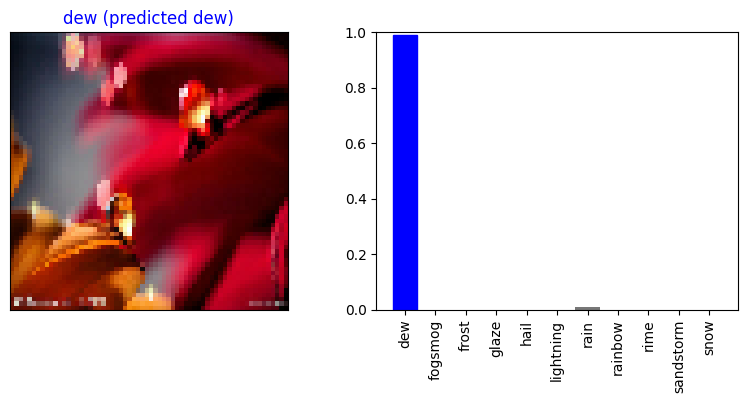

In [23]:
plot_image_prediction(0, test_images, predictions, test_labels, class_names)

In [24]:
model.layers[0].get_weights()[0].shape

(3, 3, 3, 32)

In [26]:
filters, _ = model.layers[0].get_weights()
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

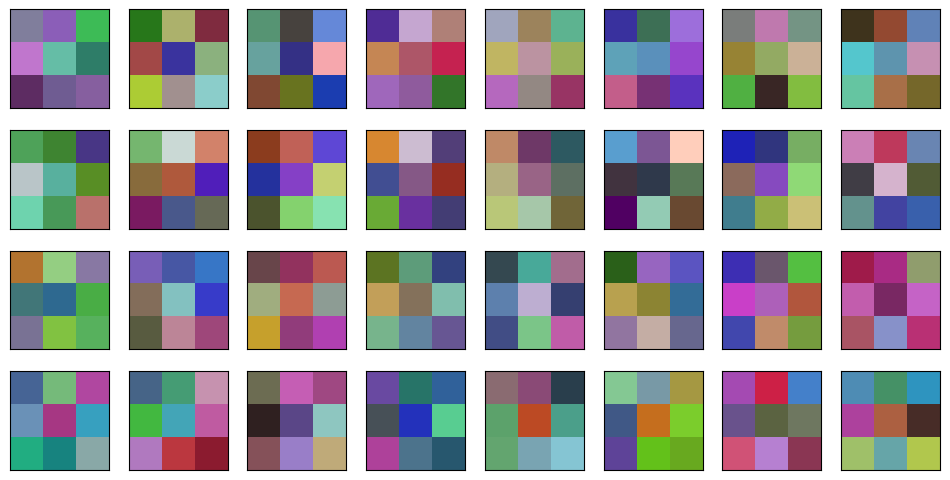

In [27]:
n_filters = filters.shape[-1]  # 32
plt.figure(figsize=(12, 6))
for i in range(n_filters):
    f = filters[:, :, :, i]
    plt.subplot(4, 8, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(f)  
plt.show()

In [28]:
n_small = 500
X_train_small = X_train[:n_small]
train_labels_small = train_labels[:n_small]
print(X_train_small.shape)

(500, 64, 64, 3)


In [30]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))

In [31]:
model.compile(optimizer='adam',
              loss=losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])

In [33]:
model.fit(X_train_small, train_labels_small,
          validation_data=(X_test, test_labels), epochs=20, batch_size=40)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9760 - loss: 0.1170 - val_accuracy: 0.5942 - val_loss: 1.6960
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.9760 - loss: 0.0978 - val_accuracy: 0.5718 - val_loss: 1.9510
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9720 - loss: 0.0988 - val_accuracy: 0.5204 - val_loss: 2.3126
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.9700 - loss: 0.1183 - val_accuracy: 0.5806 - val_loss: 1.8525
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9880 - loss: 0.0625 - val_accuracy: 0.5796 - val_loss: 1.6915
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9900 - loss: 0.0387 - val_accuracy: 0.5845 - val_loss: 1.9071
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.9980 - loss: 0.0203 - val_accuracy: 0.5738 - val_loss: 1.9459
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 0.

In [34]:
test_loss, test_acc = model.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set (without augmentation):', test_acc)

33/33 - 0s - 15ms/step - accuracy: 0.5874 - loss: 2.2271
Accuracy on test set (without augmentation): 0.5873786211013794


In [37]:
datagen = ImageDataGenerator(height_shift_range=3,
                              horizontal_flip=True)

In [39]:
model_aug = tf.keras.models.clone_model(model)

In [41]:
model_aug.compile(optimizer='adam',
                   loss=losses.sparse_categorical_crossentropy,
                   metrics=['accuracy'])

In [43]:
train_generator = datagen.flow(X_train_small, train_labels_small, seed=42, batch_size=40)

model_aug.fit(train_generator, epochs=30, validation_data=(X_test, test_labels))

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.4100 - loss: 1.6736 - val_accuracy: 0.3922 - val_loss: 1.7392
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.4600 - loss: 1.5502 - val_accuracy: 0.4126 - val_loss: 1.6893
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.4900 - loss: 1.4602 - val_accuracy: 0.4107 - val_loss: 1.6395
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.4980 - loss: 1.4185 - val_accuracy: 0.4612 - val_loss: 1.5544
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.5400 - loss: 1.3171 - val_accuracy: 0.4612 - val_loss: 1.6497
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.5800 - loss: 1.3291 - val_accuracy: 0.4388 - val_loss: 1.5802
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.5840 - loss: 1.2404 - val_accuracy: 0.5146 - val_loss: 1.5124
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.6200 - loss: 1.1918 - val_accuracy: 0.

In [44]:
test_loss, test_acc = model_aug.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set (with augmentation): ', test_acc)

33/33 - 0s - 15ms/step - accuracy: 0.5408 - loss: 2.0480
Accuracy on test set (with augmentation):  0.5407766699790955
